In [2]:
# =============================================================================
# EVAL SECTION 1 -- Setup, and load BOTH models
# =============================================================================
# Goal of this notebook: an honest before/after.
#
# The original 173 Kurankhed labels are now inside the 1,153 used for
# fine-tuning, so scoring on them would be contaminated. Instead we score BOTH
# models on the held-out validation region -- the rightmost 20% of the labelled
# area, which the fine-tuned model never trained on. Neither model has seen it,
# so the comparison is fair.

!pip -q install segmentation-models-pytorch

from google.colab import drive
drive.mount('/content/drive')

import os
import io
import time
import requests
import numpy as np
import geopandas as gpd
import rasterio
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

from PIL import Image
from shapely.ops import unary_union
from shapely.geometry import Polygon, shape, box
from rasterio.features import rasterize, shapes as rio_shapes
from rasterio.transform import from_bounds, array_bounds
from skimage.segmentation import find_boundaries, watershed
from skimage.morphology import binary_closing, disk, remove_small_objects, skeletonize, binary_dilation, h_minima
from skimage.filters import sobel
from scipy import ndimage as ndi
from scipy.ndimage import gaussian_filter
from scipy.optimize import linear_sum_assignment
from tqdm.auto import tqdm

import logging
logging.getLogger('rasterio._env').setLevel(logging.ERROR)

# --- paths -------------------------------------------------------------------
DRIVE_ROOT      = '/content/drive/MyDrive/AI4SF_BD_TF'
LABELS_PATH     = f'{DRIVE_ROOT}/kurankhed/kurn_ground_truth_4326.geojson'
FT_ROOT         = f'{DRIVE_ROOT}/finetune'
FT_PATCHES      = f'{FT_ROOT}/patches'
RASTER_PATH     = f'{FT_ROOT}/imagery/finetune_area_1m.tif'

PRETRAINED_CKPT = f'{DRIVE_ROOT}/checkpoints/best.pt'
FINETUNED_CKPT  = f'{FT_ROOT}/checkpoints/ft_best.pt'

for p in [LABELS_PATH, RASTER_PATH, PRETRAINED_CKPT, FINETUNED_CKPT]:
    assert os.path.exists(p), f"missing: {p}"
print("all inputs found")

UTM_CRS  = 'EPSG:32643'
RES_M    = 1.0
PATCH_PX = 256
VAL_FRACTION = 0.2   # must match the fine-tuning split exactly

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")


class TripleHeadModel(nn.Module):
    def __init__(self, encoder_name='efficientnet-b4', encoder_weights='imagenet', dropout_p=0.2):
        super().__init__()
        base = smp.Unet(encoder_name=encoder_name, encoder_weights=encoder_weights,
                        in_channels=3, classes=1)
        self.encoder = base.encoder
        self.decoder = base.decoder
        decoder_channels = base.decoder.blocks[-1].conv2[0].out_channels
        self.extent_dropout = nn.Dropout2d(dropout_p)
        self.boundary_dropout = nn.Dropout2d(dropout_p)
        self.extent_head = nn.Conv2d(decoder_channels, 1, kernel_size=3, padding=1)
        self.boundary_head = nn.Conv2d(decoder_channels, 1, kernel_size=3, padding=1)
        self.distance_head = nn.Conv2d(decoder_channels, 1, kernel_size=3, padding=1)

    def forward(self, x):
        features = self.encoder(x)
        decoder_out = self.decoder(features)
        extent = self.extent_head(self.extent_dropout(decoder_out))
        boundary = self.boundary_head(self.boundary_dropout(decoder_out))
        distance = self.distance_head(decoder_out)
        return extent, boundary, distance


model_before = TripleHeadModel().to(device)
c0 = torch.load(PRETRAINED_CKPT, map_location=device)
model_before.load_state_dict(c0['model'])
model_before.eval()
print(f"BEFORE model: pretrained, epoch {c0.get('epoch', '?')}")

model_after = TripleHeadModel().to(device)
c1 = torch.load(FINETUNED_CKPT, map_location=device)
model_after.load_state_dict(c1['model'])
model_after.eval()
print(f"AFTER  model: fine-tuned, epoch {c1.get('epoch', '?')}")

Mounted at /content/drive
all inputs found
device: cuda


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 77.9MB            

model.safetensors: downloading bytes:           |  0.00B            

BEFORE model: pretrained, epoch 0
AFTER  model: fine-tuned, epoch 12


full raster: 7378 x 6702 px, CRS EPSG:32643
442 patches, val split at x >= 5632 px
val region: x 5632-7378, y 0-6702 (1746 x 6702 px)
labels cleaned: 1153 -> 1150
304 fields fall inside the val region (of 1150 total)
val field area -- median 15517 m^2, min 3034, max 96486


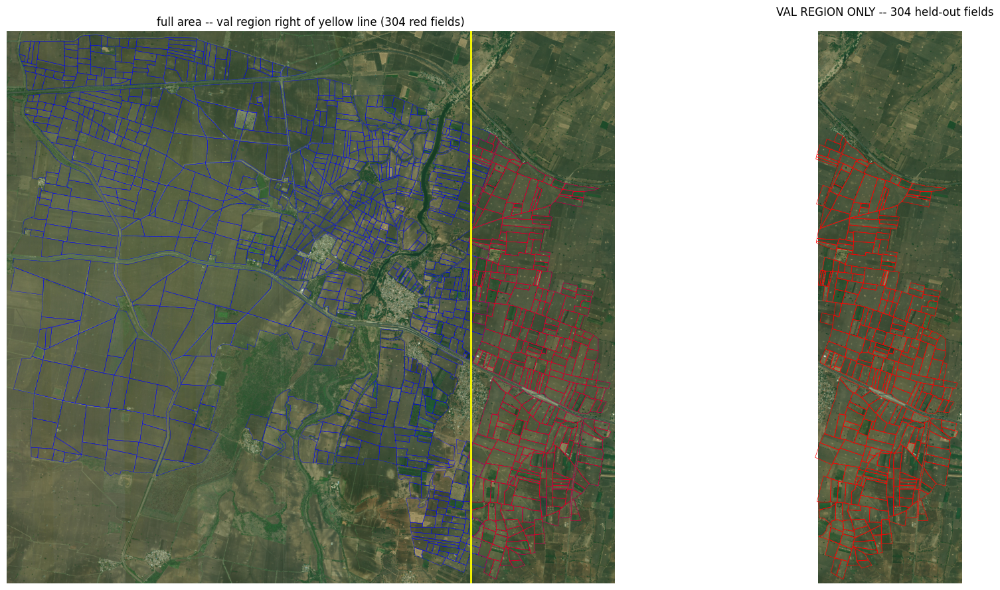

In [3]:
# =============================================================================
# EVAL SECTION 2 -- Reconstruct the held-out validation region
# =============================================================================
# The fine-tuning split was geographic: patches with x0 >= the 80th percentile
# of all patch x0 values went to validation. We recompute exactly that split
# here so the evaluation region matches what the model never trained on.

with rasterio.open(RASTER_PATH) as src:
    full_img = src.read()
    full_transform = src.transform
    crs = src.crs
    H_full, W_full = src.height, src.width
print(f"full raster: {W_full} x {H_full} px, CRS {crs}")

# recompute the split boundary
patch_files = sorted(os.listdir(FT_PATCHES))
xs = np.array([int(np.load(f'{FT_PATCHES}/{f}')['x0']) for f in patch_files])
split_x = np.quantile(xs, 1 - VAL_FRACTION)
print(f"{len(patch_files)} patches, val split at x >= {split_x:.0f} px")

val_x0 = int(split_x)
val_x1 = W_full
val_y0, val_y1 = 0, H_full
print(f"val region: x {val_x0}-{val_x1}, y {val_y0}-{val_y1} "
      f"({val_x1-val_x0} x {val_y1-val_y0} px)")

val_img = full_img[:, val_y0:val_y1, val_x0:val_x1]
left, top = full_transform * (val_x0, val_y0)
right, bottom = full_transform * (val_x1, val_y1)
val_transform = from_bounds(left, bottom, right, top,
                            val_img.shape[2], val_img.shape[1])
val_bbox = box(left, bottom, right, top)

# labels, cleaned the same way as during fine-tuning
gt_all = gpd.read_file(LABELS_PATH).to_crs(UTM_CRS)
n_before = len(gt_all)
gt_all = gt_all[gt_all.geometry.notna() & ~gt_all.geometry.is_empty].copy()
gt_all = gt_all[gt_all.geometry.area > 1.0].copy()
if (~gt_all.geometry.is_valid).any():
    try:
        from shapely import make_valid
        gt_all['geometry'] = gt_all.geometry.apply(lambda g: make_valid(g) if not g.is_valid else g)
    except ImportError:
        gt_all['geometry'] = gt_all.geometry.buffer(0)


def keep_polygons(geom):
    if geom is None:
        return None
    if geom.geom_type == 'Polygon':
        return geom
    if geom.geom_type in ('MultiPolygon', 'GeometryCollection'):
        polys = [g for g in geom.geoms if g.geom_type == 'Polygon' and g.area > 1.0]
        return max(polys, key=lambda p: p.area) if polys else None
    return None


gt_all['geometry'] = gt_all.geometry.apply(keep_polygons)
gt_all = gt_all[gt_all.geometry.notna()].copy().reset_index(drop=True)
print(f"labels cleaned: {n_before} -> {len(gt_all)}")

# keep only fields that sit MOSTLY inside the val region -- a field straddling
# the split would be unfairly penalised (half of it isn't in the image)
INSIDE_FRACTION = 0.9
frac_inside = gt_all.geometry.intersection(val_bbox).area / gt_all.geometry.area
gt_val = gt_all[frac_inside >= INSIDE_FRACTION].copy().reset_index(drop=True)
print(f"{len(gt_val)} fields fall inside the val region "
      f"(of {len(gt_all)} total)")

areas = gt_val.geometry.area
print(f"val field area -- median {areas.median():.0f} m^2, "
      f"min {areas.min():.0f}, max {areas.max():.0f}")

# visual confirmation
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fl, ft_ = full_transform * (0, H_full)
fr, ftop = full_transform * (W_full, 0)
axes[0].imshow(full_img.transpose(1, 2, 0), extent=(fl, fr, ft_, ftop))
gt_all.boundary.plot(ax=axes[0], color='blue', linewidth=0.3)
gt_val.boundary.plot(ax=axes[0], color='red', linewidth=0.4)
axes[0].axvline(left, color='yellow', linewidth=2)
axes[0].set_title(f'full area -- val region right of yellow line ({len(gt_val)} red fields)')
axes[0].axis('off')

axes[1].imshow(val_img.transpose(1, 2, 0), extent=(left, right, bottom, top))
gt_val.boundary.plot(ax=axes[1], color='red', linewidth=0.5)
axes[1].set_title(f'VAL REGION ONLY -- {len(gt_val)} held-out fields')
axes[1].axis('off')
plt.tight_layout(); plt.show()

running BEFORE (pretrained) model...


inference:   0%|          | 0/45 [00:00<?, ?it/s]

running AFTER (fine-tuned) model...


inference:   0%|          | 0/45 [00:00<?, ?it/s]


                          BEFORE     AFTER
boundary max               0.519     0.501
boundary mean             0.0722    0.0947
boundary 99th pct          0.458     0.439
extent mean                0.802     0.818


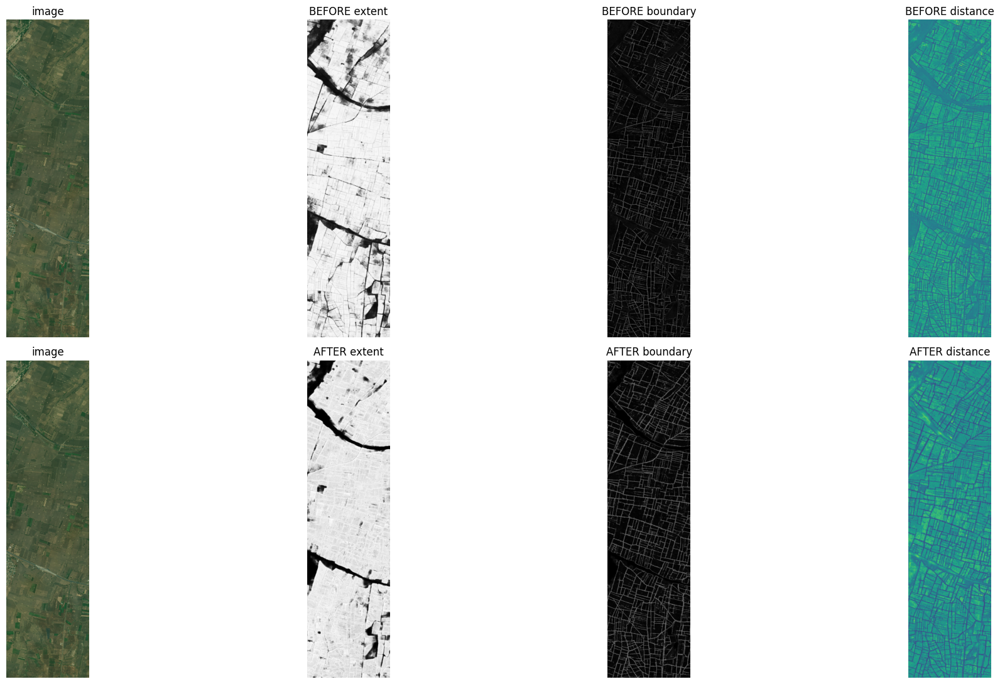

In [4]:
# =============================================================================
# EVAL SECTION 3 -- Run BOTH models over the val region
# =============================================================================
# Overlapping patches with Hann-window blending. Non-overlapping tiles leave
# visible seams at patch joins, and those seams get picked up as false field
# edges by the post-processing downstream.

def predict_smooth(model, img_uint8, device, batch_size=8, overlap=64):
    img = img_uint8.astype('float32') / 255.0
    H, W = img.shape[1], img.shape[2]
    stride = PATCH_PX - overlap
    pad_h = (stride - (H - PATCH_PX) % stride) % stride if H > PATCH_PX else PATCH_PX - H
    pad_w = (stride - (W - PATCH_PX) % stride) % stride if W > PATCH_PX else PATCH_PX - W
    img_p = np.pad(img, ((0, 0), (0, pad_h + PATCH_PX), (0, pad_w + PATCH_PX)), mode='reflect')
    Hp, Wp = img_p.shape[1], img_p.shape[2]

    acc = np.zeros((3, Hp, Wp), dtype='float32')
    wsum = np.zeros((Hp, Wp), dtype='float32')
    ramp = np.hanning(PATCH_PX)
    window = np.outer(ramp, ramp).astype('float32') + 1e-6

    coords = [(y, x) for y in range(0, Hp - PATCH_PX + 1, stride)
                      for x in range(0, Wp - PATCH_PX + 1, stride)]
    with torch.no_grad():
        for i in tqdm(range(0, len(coords), batch_size), desc='inference', leave=False):
            bc = coords[i:i + batch_size]
            bi = np.stack([img_p[:, y:y + PATCH_PX, x:x + PATCH_PX] for y, x in bc])
            e, b, d = model(torch.from_numpy(bi).to(device))
            e = torch.sigmoid(e).cpu().numpy()[:, 0]
            b = torch.sigmoid(b).cpu().numpy()[:, 0]
            d = d.cpu().numpy()[:, 0]
            for (y, x), ee, bb, dd in zip(bc, e, b, d):
                acc[0, y:y + PATCH_PX, x:x + PATCH_PX] += ee * window
                acc[1, y:y + PATCH_PX, x:x + PATCH_PX] += bb * window
                acc[2, y:y + PATCH_PX, x:x + PATCH_PX] += dd * window
                wsum[y:y + PATCH_PX, x:x + PATCH_PX] += window

    acc /= np.maximum(wsum, 1e-6)
    return acc[0, :H, :W], acc[1, :H, :W], acc[2, :H, :W]


print("running BEFORE (pretrained) model...")
ext_before, bnd_before, dist_before = predict_smooth(model_before, val_img, device)

print("running AFTER (fine-tuned) model...")
ext_after, bnd_after, dist_after = predict_smooth(model_after, val_img, device)

# --- confidence comparison ----------------------------------------------------
# The pretrained model maxed out around 0.5 on Indian imagery, which is why a
# 0.5 threshold produced an empty boundary mask. Check whether fine-tuning
# widened that range.
print(f"\n{'':22}{'BEFORE':>10}{'AFTER':>10}")
print(f"{'boundary max':22}{bnd_before.max():>10.3f}{bnd_after.max():>10.3f}")
print(f"{'boundary mean':22}{bnd_before.mean():>10.4f}{bnd_after.mean():>10.4f}")
print(f"{'boundary 99th pct':22}{np.percentile(bnd_before,99):>10.3f}{np.percentile(bnd_after,99):>10.3f}")
print(f"{'extent mean':22}{ext_before.mean():>10.3f}{ext_after.mean():>10.3f}")

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes[0, 0].imshow(val_img.transpose(1, 2, 0)); axes[0, 0].set_title('image')
axes[0, 1].imshow(ext_before, cmap='gray', vmin=0, vmax=1); axes[0, 1].set_title('BEFORE extent')
axes[0, 2].imshow(bnd_before, cmap='gray', vmin=0, vmax=1); axes[0, 2].set_title('BEFORE boundary')
axes[0, 3].imshow(dist_before, cmap='viridis'); axes[0, 3].set_title('BEFORE distance')
axes[1, 0].imshow(val_img.transpose(1, 2, 0)); axes[1, 0].set_title('image')
axes[1, 1].imshow(ext_after, cmap='gray', vmin=0, vmax=1); axes[1, 1].set_title('AFTER extent')
axes[1, 2].imshow(bnd_after, cmap='gray', vmin=0, vmax=1); axes[1, 2].set_title('AFTER boundary')
axes[1, 3].imshow(dist_after, cmap='viridis'); axes[1, 3].set_title('AFTER distance')
for ax in axes.ravel(): ax.axis('off')
plt.tight_layout(); plt.show()

In [5]:
# =============================================================================
# EVAL SECTION 4 -- Polygon extraction + metric functions
# =============================================================================
# Pipeline: combined edge strength (boundary head + distance gradient), then
# h-minima seeded watershed. Field interiors are LOW in edge strength, so each
# field is a basin -- one seed per basin, no reliance on noisy distance peaks.

def build_edge_strength(boundary_prob, distance_pred, sigma=1.0):
    dist_norm = (distance_pred - distance_pred.min()) / (np.ptp(distance_pred) + 1e-9)
    dist_edges = sobel(gaussian_filter(dist_norm, sigma=sigma))
    dist_edges = dist_edges / (dist_edges.max() + 1e-9)
    bnd_norm = boundary_prob / (boundary_prob.max() + 1e-9)
    return np.maximum(bnd_norm, dist_edges)


def extract_instances(extent_prob, boundary_prob, distance_pred,
                      extent_thresh=0.5, overseg_h=0.05, smooth_sigma=1.5,
                      min_size=200, extent_closing_radius=2):
    extent_mask = extent_prob > extent_thresh
    extent_mask = binary_closing(extent_mask, disk(extent_closing_radius))
    extent_mask = ndi.binary_fill_holes(extent_mask)

    es = gaussian_filter(build_edge_strength(boundary_prob, distance_pred),
                         sigma=smooth_sigma)

    minima = h_minima(es, overseg_h)
    markers, _ = ndi.label(minima)
    labels = watershed(es, markers, mask=extent_mask)
    labels = remove_small_objects(labels, min_size=min_size)

    # NOTE: never use ndi.label(labels > 0) here -- watershed regions touch with
    # no background between them, so it collapses everything into one blob.
    n = len(np.unique(labels)) - (1 if 0 in labels else 0)
    return labels, n


def polygonize(instance_mask, transform, crs):
    polys = [shape(geom) for geom, val in
             rio_shapes(instance_mask.astype('int32'),
                        mask=instance_mask > 0, transform=transform) if val > 0]
    if not polys:
        return gpd.GeoDataFrame({'pred_id': []}, geometry=[], crs=crs)
    return gpd.GeoDataFrame({'pred_id': range(len(polys))}, geometry=polys, crs=crs)


def match_polygons(gt_gdf, pred_gdf, iou_thresh=0.5):
    """Hungarian 1:1 matching. Strict -- a real field split into fragments
    scores as a miss even if every fragment sits correctly inside it."""
    gt_gdf = gt_gdf.reset_index(drop=True)
    pred_gdf = pred_gdf.reset_index(drop=True)
    if len(pred_gdf) == 0:
        return {'n_gt': len(gt_gdf), 'n_pred': 0, 'n_matched': 0,
                'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'mean_matched_iou': 0.0}

    joined = gpd.sjoin(gt_gdf[['geometry']], pred_gdf[['geometry']],
                       how='inner', predicate='intersects')
    iou = np.zeros((len(gt_gdf), len(pred_gdf)))
    for gi, pi in zip(joined.index, joined['index_right']):
        g, p = gt_gdf.geometry.iloc[gi], pred_gdf.geometry.iloc[pi]
        u = g.union(p).area
        if u > 0:
            iou[gi, pi] = g.intersection(p).area / u

    gi_, pi_ = linear_sum_assignment(1 - iou)
    matches = [(a, b, iou[a, b]) for a, b in zip(gi_, pi_) if iou[a, b] >= iou_thresh]
    precision = len(matches) / len(pred_gdf)
    recall = len(matches) / len(gt_gdf)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    return {'n_gt': len(gt_gdf), 'n_pred': len(pred_gdf), 'n_matched': len(matches),
            'precision': precision, 'recall': recall, 'f1': f1,
            'mean_matched_iou': float(np.mean([m[2] for m in matches])) if matches else 0.0}


def rasterize_gt(gt_gdf, out_shape, transform):
    shapes_ = [(g, i + 1) for i, g in enumerate(gt_gdf.geometry)]
    inst = rasterize(shapes_, out_shape=out_shape, transform=transform, fill=0, dtype='int32')
    bnd = find_boundaries(inst, mode='inner').astype('float32')
    bnd[inst == 0] = 0
    return (inst > 0).astype('float32'), bnd


def pixel_metrics(ext_prob, bnd_prob, gt_extent, gt_boundary,
                  extent_thresh=0.5, boundary_thresh=0.3):
    """boundary_thresh defaults to 0.3, not 0.5 -- these models' boundary
    probabilities peak below 0.5, so 0.5 yields an all-empty mask."""
    eb = ext_prob > extent_thresh
    bb = bnd_prob > boundary_thresh
    et = gt_extent > 0.5
    bt = gt_boundary > 0.5
    iou = (eb & et).sum() / max((eb | et).sum(), 1)
    tp = (bb & bt).sum(); fp = (bb & ~bt).sum(); fn = (~bb & bt).sum()
    p = tp / max(tp + fp, 1); r = tp / max(tp + fn, 1)
    return {'extent_iou': float(iou), 'boundary_precision': float(p),
            'boundary_recall': float(r), 'boundary_f1': float(2 * p * r / (p + r + 1e-6))}


gt_extent_r, gt_boundary_r = rasterize_gt(gt_val, ext_after.shape, val_transform)
print(f"rasterized ground truth: {100*gt_extent_r.mean():.1f}% field pixels, "
      f"{100*gt_boundary_r.mean():.2f}% boundary pixels")

rasterized ground truth: 49.2% field pixels, 1.47% boundary pixels



--- BEFORE (pretrained) ---
h=0.02  regions= 8707  matched=  29/304  P=0.003 R=0.095 F1=0.006  mIoU=0.640
h=0.03  regions= 5083  matched=  74/304  P=0.015 R=0.243 F1=0.027  mIoU=0.688
h=0.05  regions= 2295  matched= 175/304  P=0.076 R=0.576 F1=0.135  mIoU=0.748
h=0.08  regions= 1225  matched= 199/304  P=0.162 R=0.655 F1=0.260  mIoU=0.787
h=0.12  regions=  734  matched= 170/304  P=0.232 R=0.559 F1=0.328  mIoU=0.789
h=0.18  regions=  422  matched= 112/304  P=0.265 R=0.368 F1=0.309  mIoU=0.790
h=0.25  regions=  192  matched=  54/304  P=0.281 R=0.178 F1=0.218  mIoU=0.774
h=0.35  regions=   63  matched=  20/304  P=0.317 R=0.066 F1=0.109  mIoU=0.804
h=0.45  regions=   12  matched=   4/304  P=0.333 R=0.013 F1=0.025  mIoU=0.799


/tmp/ipykernel_2917/1927301076.py:29: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  labels = remove_small_objects(labels, min_size=min_size)


h=0.60  regions=    1  matched=   0/304  P=0.000 R=0.000 F1=0.000  mIoU=0.000
best: h=0.12  F1=0.328

--- AFTER extended ---
h=0.02  regions=10099  matched=  45/304  P=0.004 R=0.148 F1=0.009  mIoU=0.688
h=0.03  regions= 6886  matched=  86/304  P=0.012 R=0.283 F1=0.024  mIoU=0.723
h=0.05  regions= 3465  matched= 148/304  P=0.043 R=0.487 F1=0.079  mIoU=0.760
h=0.08  regions= 1718  matched= 205/304  P=0.119 R=0.674 F1=0.203  mIoU=0.782
h=0.12  regions= 1084  matched= 222/304  P=0.205 R=0.730 F1=0.320  mIoU=0.790
h=0.18  regions=  770  matched= 195/304  P=0.253 R=0.641 F1=0.363  mIoU=0.792
h=0.25  regions=  557  matched= 158/304  P=0.284 R=0.520 F1=0.367  mIoU=0.791
h=0.35  regions=  374  matched= 105/304  P=0.281 R=0.345 F1=0.310  mIoU=0.787
h=0.45  regions=  256  matched=  77/304  P=0.301 R=0.253 F1=0.275  mIoU=0.802
h=0.60  regions=  110  matched=  32/304  P=0.291 R=0.105 F1=0.155  mIoU=0.838
best: h=0.25  F1=0.367


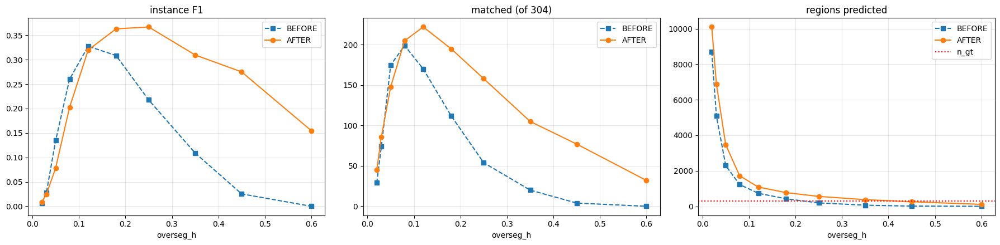

In [9]:
# =============================================================================
# EVAL SECTION 5 -- Sweep overseg_h, per model
# =============================================================================
# Each model gets its OWN best parameter. Tuning one setting on the fine-tuned
# model and applying it to the pretrained one would make the comparison unfair,
# since their probability ranges differ.

H_VALUES = [0.02, 0.03, 0.05, 0.08, 0.12, 0.18, 0.25, 0.35, 0.45, 0.60]


def sweep(ext_prob, bnd_prob, dist_pred, label):
    print(f"\n--- {label} ---")
    rows = []
    for h in H_VALUES:
        labels, n = extract_instances(ext_prob, bnd_prob, dist_pred, overseg_h=h)
        polys = polygonize(labels, val_transform, crs)
        m = match_polygons(gt_val, polys, iou_thresh=0.5)
        rows.append({'h': h, 'n_regions': n, **m})
        print(f"h={h:.2f}  regions={n:5d}  matched={m['n_matched']:4d}/{m['n_gt']}  "
              f"P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f}  "
              f"mIoU={m['mean_matched_iou']:.3f}")
    best = max(rows, key=lambda r: r['f1'])
    print(f"best: h={best['h']:.2f}  F1={best['f1']:.3f}")
    return rows, best


rows_before, best_before = sweep(ext_before, bnd_before, dist_before, 'BEFORE (pretrained)')
rows_after, best_after = sweep(ext_after, bnd_after, dist_after, 'AFTER extended')


fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for rows, lbl, style in [(rows_before, 'BEFORE', 's--'), (rows_after, 'AFTER', 'o-')]:
    hs = [r['h'] for r in rows]
    axes[0].plot(hs, [r['f1'] for r in rows], style, label=lbl)
    axes[1].plot(hs, [r['n_matched'] for r in rows], style, label=lbl)
    axes[2].plot(hs, [r['n_regions'] for r in rows], style, label=lbl)
axes[0].set_title('instance F1'); axes[1].set_title(f'matched (of {len(gt_val)})')
axes[2].set_title('regions predicted'); axes[2].axhline(len(gt_val), color='red', ls=':', label='n_gt')
for ax in axes:
    ax.set_xlabel('overseg_h'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

HELD-OUT VALIDATION REGION -- 304 fields, never trained on

INSTANCE LEVEL (IoU >= 0.5)       BEFORE     AFTER     change
n_pred                               734       770        +36
n_matched                            170       195        +25
precision                          0.232     0.253     +0.022
recall                             0.559     0.641     +0.082
f1                                 0.328     0.363     +0.036
mean_matched_iou                   0.789     0.792     +0.004

PIXEL LEVEL                       BEFORE     AFTER     change
extent_iou                         0.514     0.520     +0.006
boundary_f1                        0.163     0.148     -0.015
boundary_precision                 0.101     0.083     -0.017
boundary_recall                    0.434     0.693     +0.259

best overseg_h -- BEFORE 0.12, AFTER 0.18


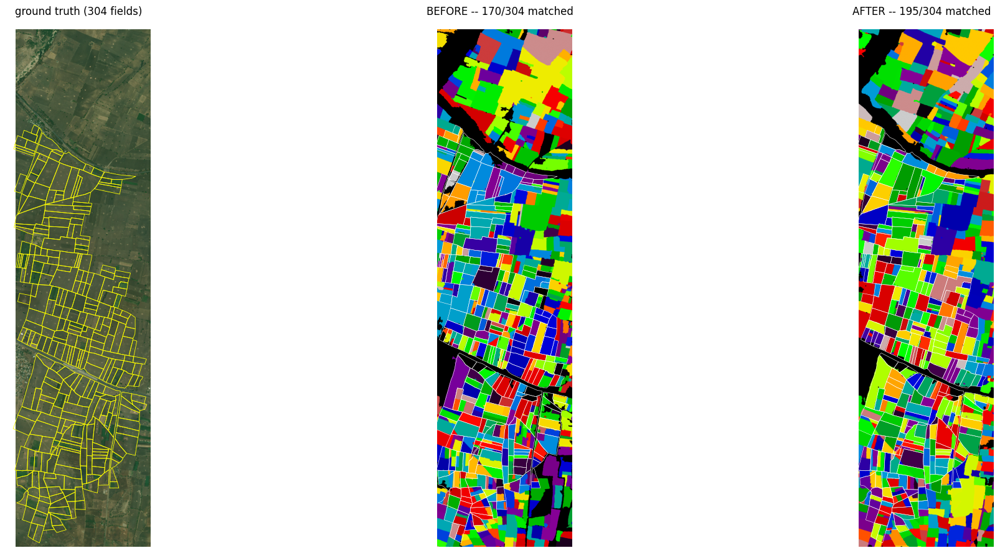

FieldError: Error adding field 'fid' to layer

In [8]:
# =============================================================================
# EVAL SECTION 6 -- Final comparison
# =============================================================================
# Each model at its own best parameter, scored on the same held-out fields.

labels_before, n_before_r = extract_instances(ext_before, bnd_before, dist_before,
                                              overseg_h=best_before['h'])
polys_before = polygonize(labels_before, val_transform, crs)

labels_after, n_after_r = extract_instances(ext_after, bnd_after, dist_after,
                                            overseg_h=best_after['h'])
polys_after = polygonize(labels_after, val_transform, crs)

inst_before = match_polygons(gt_val, polys_before, iou_thresh=0.5)
inst_after  = match_polygons(gt_val, polys_after,  iou_thresh=0.5)

px_before = pixel_metrics(ext_before, bnd_before, gt_extent_r, gt_boundary_r,
                          boundary_thresh=0.3)
px_after  = pixel_metrics(ext_after,  bnd_after,  gt_extent_r, gt_boundary_r,
                          boundary_thresh=0.3)

print("=" * 62)
print(f"HELD-OUT VALIDATION REGION -- {len(gt_val)} fields, never trained on")
print("=" * 62)
print(f"\n{'INSTANCE LEVEL (IoU >= 0.5)':<30}{'BEFORE':>10}{'AFTER':>10}{'change':>11}")
for k, fmt in [('n_pred', 'd'), ('n_matched', 'd'), ('precision', '.3f'),
               ('recall', '.3f'), ('f1', '.3f'), ('mean_matched_iou', '.3f')]:
    b, a = inst_before[k], inst_after[k]
    if fmt == 'd':
        print(f"{k:<30}{b:>10d}{a:>10d}{a-b:>+11d}")
    else:
        print(f"{k:<30}{b:>10.3f}{a:>10.3f}{a-b:>+11.3f}")

print(f"\n{'PIXEL LEVEL':<30}{'BEFORE':>10}{'AFTER':>10}{'change':>11}")
for k in ['extent_iou', 'boundary_f1', 'boundary_precision', 'boundary_recall']:
    b, a = px_before[k], px_after[k]
    print(f"{k:<30}{b:>10.3f}{a:>10.3f}{a-b:>+11.3f}")

print(f"\nbest overseg_h -- BEFORE {best_before['h']:.2f}, AFTER {best_after['h']:.2f}")


def shuffled(lbl):
    mx = int(lbl.max())
    rng = np.random.RandomState(0)
    lut = np.zeros(mx + 1, dtype=np.int64)
    if mx > 0:
        lut[1:] = rng.permutation(mx) + 1
    return lut[lbl]


ext_geo = (left, right, bottom, top)
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
axes[0].imshow(val_img.transpose(1, 2, 0), extent=ext_geo)
gt_val.boundary.plot(ax=axes[0], color='yellow', linewidth=0.6)
axes[0].set_title(f'ground truth ({len(gt_val)} fields)')
axes[1].imshow(shuffled(labels_before), cmap='nipy_spectral', extent=ext_geo)
gt_val.boundary.plot(ax=axes[1], color='white', linewidth=0.4)
axes[1].set_title(f"BEFORE -- {inst_before['n_matched']}/{len(gt_val)} matched")
axes[2].imshow(shuffled(labels_after), cmap='nipy_spectral', extent=ext_geo)
gt_val.boundary.plot(ax=axes[2], color='white', linewidth=0.4)
axes[2].set_title(f"AFTER -- {inst_after['n_matched']}/{len(gt_val)} matched")
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

OUT_DIR = f'{FT_ROOT}/eval_output'
os.makedirs(OUT_DIR, exist_ok=True)
polys_after.to_file(f'{OUT_DIR}/predicted_finetuned.gpkg', driver='GPKG')
polys_before.to_file(f'{OUT_DIR}/predicted_pretrained.gpkg', driver='GPKG')
gt_val.drop(columns=[c for c in ['fid'] if c in gt_val.columns]).to_file(
    f'{OUT_DIR}/ground_truth_val.gpkg', driver='GPKG')
print(f"saved to {OUT_DIR}")
print(f"\nsaved polygons to {OUT_DIR} -- open in QGIS to inspect")

RAW           vertices= 209362  n=  770  matched= 195  F1=0.363  mIoU=0.792

--- RDP simplification (tolerance in metres) ---
tol= 0.5m  vertices= 168960  n=  770  matched= 195  F1=0.363  mIoU=0.792
tol= 1.0m  vertices=  45491  n=  770  matched= 195  F1=0.363  mIoU=0.792
tol= 2.0m  vertices=  20499  n=  770  matched= 195  F1=0.363  mIoU=0.792
tol= 3.0m  vertices=  13701  n=  770  matched= 195  F1=0.363  mIoU=0.790
tol= 5.0m  vertices=   8415  n=  770  matched= 195  F1=0.363  mIoU=0.788
tol= 8.0m  vertices=   5745  n=  770  matched= 196  F1=0.365  mIoU=0.779

--- dagger removal (max notch width in metres) ---
width= 2.0m  n=  770  matched= 195  F1=0.363  mIoU=0.793
width= 4.0m  n=  770  matched= 195  F1=0.363  mIoU=0.791
width= 6.0m  n=  770  matched= 195  F1=0.363  mIoU=0.790
width=10.0m  n=  770  matched= 194  F1=0.361  mIoU=0.782

--- combinations ---
simplify only                n=  770  matched= 195  P=0.253 R=0.641 F1=0.363  mIoU=0.792
daggers only                 n=  770  matched

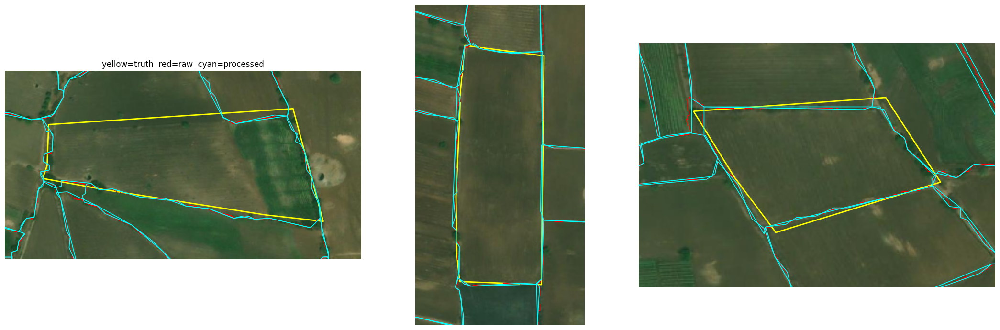

saved /content/drive/MyDrive/AI4SF_BD_TF/finetune/eval_output/predicted_postprocessed.gpkg


In [10]:
# =============================================================================
# EVAL SECTION 7 -- Polygon post-processing, measured against ground truth
# =============================================================================
# Three techniques, each measured rather than assumed:
#
#   1. RDP simplification (Douglas-Peucker) -- drop redundant vertices. Raster
#      polygonization produces staircase edges with a vertex every pixel; real
#      field boundaries are straight lines.
#   2. Dagger removal (Google ALU's method) -- find thin inward protrusions by
#      differencing against the convex hull, then close the polygon at the
#      dagger's base. Fixes spikes caused by noisy boundary predictions.
#   3. Rectangularity snapping -- for polygons that are already nearly
#      rectangular, snap to the minimum rotated rectangle.
#
# IMPORTANT CAVEAT ON TOPOLOGY: these operate per-polygon, so shared edges
# between neighbouring fields are simplified independently and will no longer
# match exactly -- leaving slivers and small overlaps. That's cosmetically fine
# for area measurement but wrong if you need a clean coverage layer. The proper
# fix is arc-based simplification (`topojson` package) which simplifies each
# shared arc once; see the optional block at the end.

from shapely.geometry import MultiPolygon


def remove_daggers(poly, max_notch_width_m=4.0, min_notch_area_m2=20.0):
    """Google ALU 'dagger removal'. A dagger is a thin inward protrusion -- it
    shows up as a narrow notch when you subtract the polygon from its convex
    hull. Narrow is tested by erosion: if eroding by half the max width empties
    the notch, it's a dagger rather than a genuine concave bay."""
    if poly.is_empty or not poly.is_valid:
        return poly
    notches = poly.convex_hull.difference(poly)
    if notches.is_empty:
        return poly

    parts = list(notches.geoms) if hasattr(notches, 'geoms') else [notches]
    fill = []
    for n in parts:
        if n.area < min_notch_area_m2:
            continue                                   # too small to matter
        if n.buffer(-max_notch_width_m / 2).is_empty:  # narrow => dagger
            fill.append(n)

    if not fill:
        return poly
    out = unary_union([poly] + fill)
    if isinstance(out, MultiPolygon):
        out = max(out.geoms, key=lambda g: g.area)
    return out


def snap_to_rectangle(poly, rectangularity_thresh=0.92):
    """If a polygon already fills most of its minimum rotated rectangle, it IS
    a rectangle and the wobble is prediction noise. Leaves irregular fields
    alone -- set the threshold high or this will distort real shapes."""
    if poly.is_empty or poly.area <= 0:
        return poly
    mrr = poly.minimum_rotated_rectangle
    if mrr.area <= 0:
        return poly
    if poly.area / mrr.area >= rectangularity_thresh:
        return mrr
    return poly


def postprocess_polygons(gdf, simplify_tol=0.0, do_daggers=False,
                         do_rectangle=False, min_area_m2=0.0,
                         max_notch_width_m=4.0, rectangularity_thresh=0.92):
    out = gdf.copy()
    geoms = out.geometry.tolist()

    if do_daggers:
        geoms = [remove_daggers(g, max_notch_width_m) for g in geoms]
    if simplify_tol > 0:
        geoms = [g.simplify(simplify_tol, preserve_topology=True) for g in geoms]
    if do_rectangle:
        geoms = [snap_to_rectangle(g, rectangularity_thresh) for g in geoms]

    out['geometry'] = geoms
    out = out[out.geometry.notna() & ~out.geometry.is_empty]
    out = out[out.geometry.is_valid]
    if min_area_m2 > 0:
        out = out[out.geometry.area >= min_area_m2]
    return out.reset_index(drop=True)


def vertex_count(gdf):
    return sum(len(g.exterior.coords) for g in gdf.geometry if g.geom_type == 'Polygon')


# =============================================================================
# Baseline: the raw polygons from section 6 (AFTER model at its best h)
# =============================================================================
base = match_polygons(gt_val, polys_after, iou_thresh=0.5)
print(f"RAW           vertices={vertex_count(polys_after):7d}  "
      f"n={len(polys_after):5d}  matched={base['n_matched']:4d}  "
      f"F1={base['f1']:.3f}  mIoU={base['mean_matched_iou']:.3f}")

# =============================================================================
# 1. RDP simplification sweep
# =============================================================================
print("\n--- RDP simplification (tolerance in metres) ---")
for tol in [0.5, 1.0, 2.0, 3.0, 5.0, 8.0]:
    p = postprocess_polygons(polys_after, simplify_tol=tol)
    m = match_polygons(gt_val, p, iou_thresh=0.5)
    print(f"tol={tol:4.1f}m  vertices={vertex_count(p):7d}  n={len(p):5d}  "
          f"matched={m['n_matched']:4d}  F1={m['f1']:.3f}  mIoU={m['mean_matched_iou']:.3f}")

# =============================================================================
# 2. Dagger removal (ALU), on its own
# =============================================================================
print("\n--- dagger removal (max notch width in metres) ---")
for w in [2.0, 4.0, 6.0, 10.0]:
    p = postprocess_polygons(polys_after, do_daggers=True, max_notch_width_m=w)
    m = match_polygons(gt_val, p, iou_thresh=0.5)
    print(f"width={w:4.1f}m  n={len(p):5d}  matched={m['n_matched']:4d}  "
          f"F1={m['f1']:.3f}  mIoU={m['mean_matched_iou']:.3f}")

# =============================================================================
# 3. Combined -- set these from the two sweeps above
# =============================================================================
BEST_TOL     = 2.0
BEST_NOTCH   = 4.0
MIN_AREA_M2  = gt_val.geometry.area.median() * 0.10   # 10% of a typical field

print("\n--- combinations ---")
combos = [
    ('simplify only',            dict(simplify_tol=BEST_TOL)),
    ('daggers only',             dict(do_daggers=True, max_notch_width_m=BEST_NOTCH)),
    ('daggers + simplify',       dict(do_daggers=True, max_notch_width_m=BEST_NOTCH,
                                      simplify_tol=BEST_TOL)),
    ('daggers + simplify + area',dict(do_daggers=True, max_notch_width_m=BEST_NOTCH,
                                      simplify_tol=BEST_TOL, min_area_m2=MIN_AREA_M2)),
    ('all + rectangle snap',     dict(do_daggers=True, max_notch_width_m=BEST_NOTCH,
                                      simplify_tol=BEST_TOL, min_area_m2=MIN_AREA_M2,
                                      do_rectangle=True)),
]
results = []
for name, kw in combos:
    p = postprocess_polygons(polys_after, **kw)
    m = match_polygons(gt_val, p, iou_thresh=0.5)
    results.append((name, kw, p, m))
    print(f"{name:28s} n={len(p):5d}  matched={m['n_matched']:4d}  "
          f"P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f}  "
          f"mIoU={m['mean_matched_iou']:.3f}")

best_name, best_kw, best_polys, best_m = max(results, key=lambda r: r[3]['f1'])
print(f"\nbest combination: {best_name}  (F1 {best_m['f1']:.3f} vs raw {base['f1']:.3f})")

# =============================================================================
# Visual check -- zoom on a few fields, raw vs processed
# =============================================================================
sample = gt_val.sample(min(3, len(gt_val)), random_state=1)
fig, axes = plt.subplots(1, len(sample), figsize=(7 * len(sample), 7))
if len(sample) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, sample.iterrows()):
    minx, miny, maxx, maxy = row.geometry.bounds
    pad = 40
    win = box(minx - pad, miny - pad, maxx + pad, maxy + pad)
    ax.imshow(val_img.transpose(1, 2, 0), extent=(left, right, bottom, top))
    gpd.GeoSeries([row.geometry], crs=crs).boundary.plot(ax=ax, color='yellow', linewidth=2.0)
    polys_after[polys_after.intersects(win)].boundary.plot(ax=ax, color='red', linewidth=0.8)
    best_polys[best_polys.intersects(win)].boundary.plot(ax=ax, color='cyan', linewidth=1.2)
    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)
    ax.axis('off')
axes[0].set_title('yellow=truth  red=raw  cyan=processed')
plt.tight_layout(); plt.show()

OUT_DIR = f'{FT_ROOT}/eval_output'
os.makedirs(OUT_DIR, exist_ok=True)
best_polys.to_file(f'{OUT_DIR}/predicted_postprocessed.gpkg', driver='GPKG')
print(f"saved {OUT_DIR}/predicted_postprocessed.gpkg")



In [11]:
med = gt_val.geometry.area.median()
print(f"median GT field area: {med:.0f} m^2")
for frac in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]:
    p = postprocess_polygons(polys_after, do_daggers=True, max_notch_width_m=2.0,
                             simplify_tol=2.0, min_area_m2=med * frac)
    m = match_polygons(gt_val, p, iou_thresh=0.5)
    print(f"min_area={frac:.2f}x median ({med*frac:7.0f} m^2)  n={len(p):5d}  "
          f"matched={m['n_matched']:4d}  P={m['precision']:.3f} R={m['recall']:.3f} "
          f"F1={m['f1']:.3f}")

median GT field area: 15517 m^2
min_area=0.05x median (    776 m^2)  n=  664  matched= 195  P=0.294 R=0.641 F1=0.403
min_area=0.10x median (   1552 m^2)  n=  616  matched= 195  P=0.317 R=0.641 F1=0.424
min_area=0.15x median (   2328 m^2)  n=  581  matched= 195  P=0.336 R=0.641 F1=0.441
min_area=0.20x median (   3103 m^2)  n=  553  matched= 194  P=0.351 R=0.638 F1=0.453
min_area=0.30x median (   4655 m^2)  n=  505  matched= 188  P=0.372 R=0.618 F1=0.465
min_area=0.40x median (   6207 m^2)  n=  473  matched= 185  P=0.391 R=0.609 F1=0.476


In [ ]:

# =============================================================================
# OPTIONAL -- topology-preserving simplification (shared edges stay matched)
# =============================================================================
# Per-polygon simplify() above leaves slivers between neighbours. topojson
# converts to shared arcs, simplifies each arc once, and rebuilds -- so
# adjacent fields keep identical shared boundaries. Worth it if you need a
# clean coverage layer rather than independent field shapes.
#
# !pip -q install topojson
#
# import topojson as tp
# topo = tp.Topology(best_polys.to_crs(crs), prequantize=False)
# clean = topo.toposimplify(BEST_TOL).to_gdf()
# clean = clean[clean.geometry.is_valid & ~clean.geometry.is_empty]
# m = match_polygons(gt_val, clean, iou_thresh=0.5)
# print(f"topology-preserving: n={len(clean)} matched={m['n_matched']} F1={m['f1']:.3f}")
# clean.to_file(f'{OUT_DIR}/predicted_topo_simplified.gpkg', driver='GPKG')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.1 MB/s eta 0:00:00
Mounted at /content/drive


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 77.9MB            

model.safetensors: downloading bytes:           |  0.00B            

model loaded (epoch 12) on cuda
area: 3.0x3.0 km -> 3016x2998 px at 1 m/px


fetching:   0%|          | 0/3 [00:00<?, ?it/s]

imagery saved: /content/drive/MyDrive/AI4SF_BD_TF/inference_output/site4_imagery.tif


inference:   0%|          | 0/37 [00:00<?, ?it/s]

predictions: extent mean 0.604, boundary max 0.501
raw regions: 925
post-processing: 925 -> 846 polygons, vertices 210879 -> 25075 (88% reduction)

846 fields  |  total 762.7 ha
field size -- median 0.61 ha, min 0.05, max 26.00

  /content/drive/MyDrive/AI4SF_BD_TF/inference_output/site4_fields.gpkg   (UTM 43N -- use this in QGIS)
  /content/drive/MyDrive/AI4SF_BD_TF/inference_output/site4_fields.geojson  (WGS84 lat/lon -- for web maps)
  /content/drive/MyDrive/AI4SF_BD_TF/inference_output/site4_imagery.tif


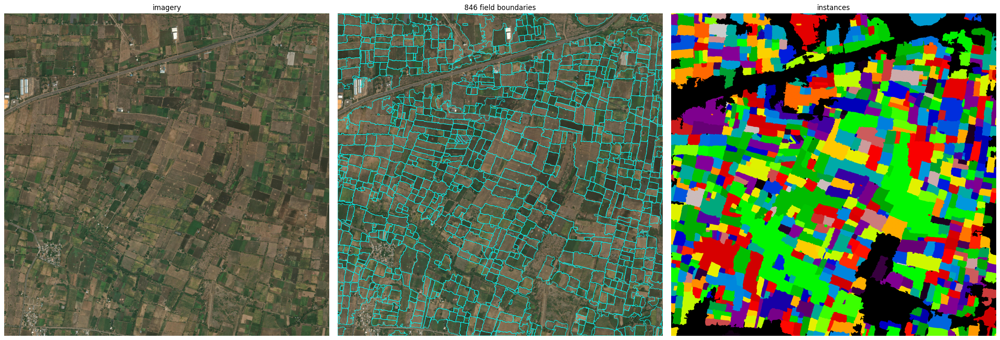

In [1]:
# =============================================================================
# STANDALONE INFERENCE -- coordinates in, field polygons out
# =============================================================================
# Self-contained. Paste into a fresh Colab notebook as ONE cell, set the
# coordinates at the top, run. Outputs .gpkg + .geojson ready for QGIS.

!pip -q install segmentation-models-pytorch

CENTER_LAT  = 17.702059
CENTER_LON  = 76.006878
BOX_KM      = 3.0             # square side length in km
SITE_NAME    = 'site4'      # used for output filenames


from google.colab import drive
drive.mount('/content/drive')

import os, io, time, requests
import numpy as np
import geopandas as gpd
import rasterio
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

from PIL import Image
from shapely.geometry import shape, MultiPolygon
from shapely.ops import unary_union
from rasterio.features import shapes as rio_shapes
from rasterio.transform import from_bounds
from rasterio.warp import transform_bounds
from skimage.segmentation import watershed
from skimage.morphology import binary_closing, disk, remove_small_objects, h_minima
from skimage.filters import sobel
from scipy import ndimage as ndi
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

import logging
logging.getLogger('rasterio._env').setLevel(logging.ERROR)

DRIVE_ROOT = '/content/drive/MyDrive/AI4SF_BD_TF'
CKPT_PATH  = f'{DRIVE_ROOT}/finetune/checkpoints/ft_best.pt'   # fine-tuned model
OUT_DIR    = f'{DRIVE_ROOT}/inference_output'
os.makedirs(OUT_DIR, exist_ok=True)

UTM_CRS  = 'EPSG:32643'   # UTM 43N -- correct for Vidarbha / western-central India
RES_M    = 1.0
PATCH_PX = 256
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- tuned settings (from the held-out evaluation: F1 0.421) ------------------
OVERSEG_H        = 0.18    # h-minima depth; lower = more regions
EXTENT_THRESH    = 0.5
SIMPLIFY_TOL_M   = 2.0     # 90% fewer vertices, no accuracy cost
DAGGER_WIDTH_M   = 2.0     # ALU-style spike removal
MIN_AREA_FRAC    = 0.10    # drop polygons under this fraction of median area
                            # (this filter was the single biggest accuracy win)

# =============================================================================
# 1. model
# =============================================================================
class TripleHeadModel(nn.Module):
    def __init__(self, encoder_name='efficientnet-b4', encoder_weights='imagenet', dropout_p=0.2):
        super().__init__()
        base = smp.Unet(encoder_name=encoder_name, encoder_weights=encoder_weights,
                        in_channels=3, classes=1)
        self.encoder, self.decoder = base.encoder, base.decoder
        dc = base.decoder.blocks[-1].conv2[0].out_channels
        self.extent_dropout = nn.Dropout2d(dropout_p)
        self.boundary_dropout = nn.Dropout2d(dropout_p)
        self.extent_head = nn.Conv2d(dc, 1, 3, padding=1)
        self.boundary_head = nn.Conv2d(dc, 1, 3, padding=1)
        self.distance_head = nn.Conv2d(dc, 1, 3, padding=1)

    def forward(self, x):
        f = self.encoder(x)
        d = self.decoder(f)
        return (self.extent_head(self.extent_dropout(d)),
                self.boundary_head(self.boundary_dropout(d)),
                self.distance_head(d))

assert os.path.exists(CKPT_PATH), f"missing checkpoint: {CKPT_PATH}"
model = TripleHeadModel().to(device)
_ck = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(_ck['model'])
model.eval()
print(f"model loaded (epoch {_ck.get('epoch','?')}) on {device}")

# =============================================================================
# 2. fetch imagery -- native UTM at 1 m/px, matching how the model was trained
# =============================================================================
ESRI_URL = 'https://services.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer/export'
MAX_CHUNK_PX = 1200

half_deg_lat = (BOX_KM / 2) / 111.320
half_deg_lon = (BOX_KM / 2) / (111.320 * np.cos(np.radians(CENTER_LAT)))
minx, miny, maxx, maxy = transform_bounds(
    'EPSG:4326', UTM_CRS,
    CENTER_LON - half_deg_lon, CENTER_LAT - half_deg_lat,
    CENTER_LON + half_deg_lon, CENTER_LAT + half_deg_lat)

w_px, h_px = int(round((maxx-minx)/RES_M)), int(round((maxy-miny)/RES_M))
print(f"area: {BOX_KM}x{BOX_KM} km -> {w_px}x{h_px} px at 1 m/px")

def fetch_chunk(x0, y0, x1, y1, w, h, retries=4):
    params = {'bbox': f'{x0},{y0},{x1},{y1}', 'bboxSR': 32643, 'imageSR': 32643,
              'size': f'{w},{h}', 'format': 'png32', 'f': 'image'}
    for a in range(retries):
        try:
            r = requests.get(ESRI_URL, params=params, timeout=60)
            r.raise_for_status()
            if 'image' not in r.headers.get('Content-Type', ''):
                raise ValueError(f"non-image response: {r.text[:150]}")
            return np.array(Image.open(io.BytesIO(r.content)).convert('RGB')).transpose(2, 0, 1)
        except Exception as e:
            print(f"    retry {a+1}/{retries}: {e}")
            time.sleep(2 ** a)
    raise RuntimeError("fetch failed")

nx, ny = int(np.ceil(w_px/MAX_CHUNK_PX)), int(np.ceil(h_px/MAX_CHUNK_PX))
cw, ch = (maxx-minx)/nx, (maxy-miny)/ny
tiles = {}
for i in tqdm(range(nx), desc='fetching'):
    for j in range(ny):
        tiles[(i, j)] = fetch_chunk(minx+i*cw, miny+j*ch, minx+(i+1)*cw, miny+(j+1)*ch,
                                     int(round(cw/RES_M)), int(round(ch/RES_M)))
        time.sleep(1.0)

# rows build bottom-up in world coords, so reverse j for array order
mosaic = np.concatenate(
    [np.concatenate([tiles[(i, j)] for j in reversed(range(ny))], axis=1) for i in range(nx)], axis=2)
transform = from_bounds(minx, miny, maxx, maxy, mosaic.shape[2], mosaic.shape[1])

raster_path = f'{OUT_DIR}/{SITE_NAME}_imagery.tif'
with rasterio.open(raster_path, 'w', driver='GTiff', dtype='uint8', count=3,
                   height=mosaic.shape[1], width=mosaic.shape[2],
                   crs=UTM_CRS, transform=transform) as dst:
    dst.write(mosaic)
print(f"imagery saved: {raster_path}")

# =============================================================================
# 3. inference -- overlapping windows, Hann blending (avoids patch-seam artifacts)
# =============================================================================
def predict(model, img_uint8, overlap=64, batch_size=8):
    img = img_uint8.astype('float32') / 255.0
    H, W = img.shape[1], img.shape[2]
    stride = PATCH_PX - overlap
    ph = (stride - (H - PATCH_PX) % stride) % stride if H > PATCH_PX else PATCH_PX - H
    pw = (stride - (W - PATCH_PX) % stride) % stride if W > PATCH_PX else PATCH_PX - W
    ip = np.pad(img, ((0,0),(0,ph+PATCH_PX),(0,pw+PATCH_PX)), mode='reflect')
    Hp, Wp = ip.shape[1], ip.shape[2]
    acc, wsum = np.zeros((3,Hp,Wp), 'float32'), np.zeros((Hp,Wp), 'float32')
    ramp = np.hanning(PATCH_PX)
    win = np.outer(ramp, ramp).astype('float32') + 1e-6
    coords = [(y,x) for y in range(0, Hp-PATCH_PX+1, stride) for x in range(0, Wp-PATCH_PX+1, stride)]
    with torch.no_grad():
        for i in tqdm(range(0, len(coords), batch_size), desc='inference', leave=False):
            bc = coords[i:i+batch_size]
            bi = np.stack([ip[:, y:y+PATCH_PX, x:x+PATCH_PX] for y,x in bc])
            e,b,d = model(torch.from_numpy(bi).to(device))
            e = torch.sigmoid(e).cpu().numpy()[:,0]
            b = torch.sigmoid(b).cpu().numpy()[:,0]
            d = d.cpu().numpy()[:,0]
            for (y,x), ee, bb, dd in zip(bc, e, b, d):
                acc[0, y:y+PATCH_PX, x:x+PATCH_PX] += ee*win
                acc[1, y:y+PATCH_PX, x:x+PATCH_PX] += bb*win
                acc[2, y:y+PATCH_PX, x:x+PATCH_PX] += dd*win
                wsum[y:y+PATCH_PX, x:x+PATCH_PX] += win
    acc /= np.maximum(wsum, 1e-6)
    return acc[0,:H,:W], acc[1,:H,:W], acc[2,:H,:W]

extent_prob, boundary_prob, distance_pred = predict(model, mosaic)
print(f"predictions: extent mean {extent_prob.mean():.3f}, boundary max {boundary_prob.max():.3f}")

# =============================================================================
# 4. instance extraction -- h-minima seeded watershed on combined edge strength
# =============================================================================
# Field interiors are LOW in edge strength, so each field is a basin. One seed
# per basin -- avoids the noisy-distance-peak problem that over-segments badly.
dist_norm = (distance_pred - distance_pred.min()) / (np.ptp(distance_pred) + 1e-9)
dist_edges = sobel(gaussian_filter(dist_norm, sigma=1.0))
dist_edges /= (dist_edges.max() + 1e-9)
edge_strength = np.maximum(boundary_prob / (boundary_prob.max() + 1e-9), dist_edges)
edge_smooth = gaussian_filter(edge_strength, sigma=1.5)

extent_mask = ndi.binary_fill_holes(binary_closing(extent_prob > EXTENT_THRESH, disk(2)))
markers, _ = ndi.label(h_minima(edge_smooth, OVERSEG_H))
labels = watershed(edge_smooth, markers, mask=extent_mask)
labels = remove_small_objects(labels, min_size=200)
n_raw = len(np.unique(labels)) - (1 if 0 in labels else 0)
print(f"raw regions: {n_raw}")

polys = [shape(g) for g, v in rio_shapes(labels.astype('int32'),
                                          mask=labels > 0, transform=transform) if v > 0]
gdf = gpd.GeoDataFrame({'id': range(len(polys))}, geometry=polys, crs=UTM_CRS)

# =============================================================================
# 5. post-processing
# =============================================================================
def remove_daggers(poly, max_w=2.0, min_area=20.0):
    """Google ALU 'dagger removal' -- thin inward spikes show up as narrow
    notches vs the convex hull. Narrow is tested by erosion."""
    if poly.is_empty or not poly.is_valid:
        return poly
    notches = poly.convex_hull.difference(poly)
    if notches.is_empty:
        return poly
    parts = list(notches.geoms) if hasattr(notches, 'geoms') else [notches]
    fill = [n for n in parts if n.area >= min_area and n.buffer(-max_w/2).is_empty]
    if not fill:
        return poly
    out = unary_union([poly] + fill)
    return max(out.geoms, key=lambda g: g.area) if isinstance(out, MultiPolygon) else out

v_before = sum(len(g.exterior.coords) for g in gdf.geometry if g.geom_type == 'Polygon')

gdf['geometry'] = [remove_daggers(g, DAGGER_WIDTH_M) for g in gdf.geometry]
gdf['geometry'] = [g.simplify(SIMPLIFY_TOL_M, preserve_topology=True) for g in gdf.geometry]
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty & gdf.geometry.is_valid]

med_area = gdf.geometry.area.median()
gdf = gdf[gdf.geometry.area >= med_area * MIN_AREA_FRAC].reset_index(drop=True)

v_after = sum(len(g.exterior.coords) for g in gdf.geometry if g.geom_type == 'Polygon')
print(f"post-processing: {n_raw} -> {len(gdf)} polygons, "
      f"vertices {v_before} -> {v_after} ({100*(1-v_after/max(v_before,1)):.0f}% reduction)")

gdf['area_m2'] = gdf.geometry.area.round(1)
gdf['area_ha'] = (gdf.geometry.area / 10000).round(3)
gdf['perimeter_m'] = gdf.geometry.length.round(1)
gdf = gdf[['id', 'area_m2', 'area_ha', 'perimeter_m', 'geometry']]

# =============================================================================
# 6. save + preview
# =============================================================================
gpkg = f'{OUT_DIR}/{SITE_NAME}_fields.gpkg'
gjson = f'{OUT_DIR}/{SITE_NAME}_fields.geojson'
gdf.to_file(gpkg, driver='GPKG')
gdf.to_crs('EPSG:4326').to_file(gjson, driver='GeoJSON')   # WGS84 for web tools

print(f"\n{'='*58}")
print(f"{len(gdf)} fields  |  total {gdf.area_ha.sum():.1f} ha")
print(f"field size -- median {gdf.area_ha.median():.2f} ha, "
      f"min {gdf.area_ha.min():.2f}, max {gdf.area_ha.max():.2f}")
print(f"\n  {gpkg}   (UTM 43N -- use this in QGIS)")
print(f"  {gjson}  (WGS84 lat/lon -- for web maps)")
print(f"  {raster_path}")
print('='*58)

left, top = transform * (0, 0)
right, bottom = transform * (mosaic.shape[2], mosaic.shape[1])
ext = (left, right, bottom, top)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
axes[0].imshow(mosaic.transpose(1,2,0), extent=ext); axes[0].set_title('imagery')
axes[1].imshow(mosaic.transpose(1,2,0), extent=ext)
gdf.boundary.plot(ax=axes[1], color='cyan', linewidth=0.7)
axes[1].set_title(f'{len(gdf)} field boundaries')
mx = int(labels.max())
lut = np.zeros(mx+1, dtype=np.int64)
if mx > 0:
    lut[1:] = np.random.RandomState(0).permutation(mx) + 1
axes[2].imshow(lut[labels], cmap='nipy_spectral', extent=ext); axes[2].set_title('instances')
for a in axes: a.axis('off')
plt.tight_layout(); plt.show()

predicted field area (m^2):
  50th percentile:      5358
  75th percentile:      9721
  90th percentile:     16749
  95th percentile:     23478
  98th percentile:     39518
  99th percentile:     56731
  max            :    259969
  median         :      5358

re-split threshold: 23478 m^2  (47 polygons affected)


re-splitting:   0%|          | 0/47 [00:00<?, ?it/s]

split 47 of 47 oversized regions
regions: 925 -> 1163
vertices: 29093 (pre-smooth) -> 49545 (post-smooth+simplify)

final: 1028 fields (was 846)
area -- median 0.56 ha, p95 1.98, max 11.94
saved /content/drive/MyDrive/AI4SF_BD_TF/inference_output/site4_fields_v2.gpkg


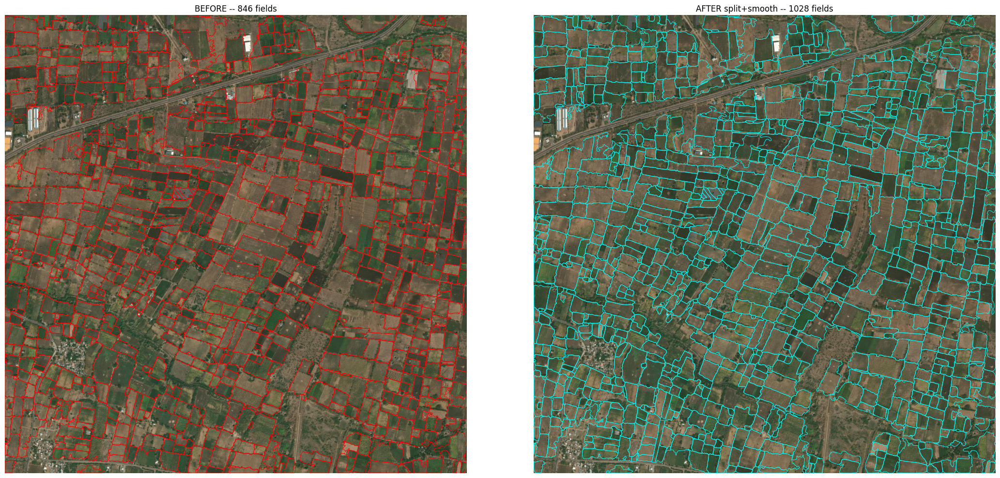

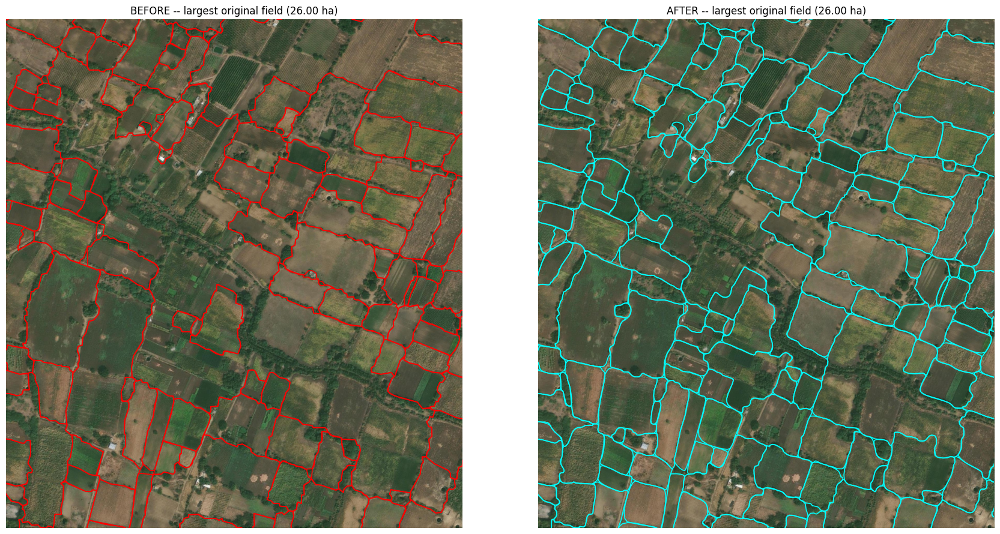

In [2]:
# =============================================================================
# ADD-ON -- split merged fields + smooth jagged boundaries
# =============================================================================
# Run AFTER the standalone inference script, in the same session. It reuses
# `labels`, `edge_smooth`, `extent_mask`, `transform`, `mosaic`, `gdf`.
#
# Two separate problems, two separate fixes:
#
#   MERGED FIELDS -- the watershed found one basin where there are really
#     several. Fix by re-running watershed INSIDE each oversized region with a
#     progressively lower h until it splits. Do NOT just delete large polygons:
#     that throws the area away, and some fields genuinely are large.
#
#   JAGGED EDGES -- raster polygonization gives staircase edges; RDP thins the
#     vertices but leaves the corners sharp. Chaikin corner-cutting rounds them.

from shapely.geometry import Polygon

# =============================================================================
# 0. Decide what "oversized" means -- from the data, not a guess
# =============================================================================
px_area = abs(transform.a) * abs(transform.e)          # m^2 per pixel
sizes_px = np.array([(labels == i).sum() for i in np.unique(labels) if i != 0])
sizes_m2 = sizes_px * px_area

print("predicted field area (m^2):")
for p in [50, 75, 90, 95, 98, 99]:
    print(f"  {p}th percentile: {np.percentile(sizes_m2, p):9.0f}")
print(f"  max            : {sizes_m2.max():9.0f}")
print(f"  median         : {np.median(sizes_m2):9.0f}")

# Anything above this gets a re-split attempt. Start at the 95th percentile --
# if your ground truth shows real fields that big, raise it.
OVERSIZE_THRESH_M2 = np.percentile(sizes_m2, 95)
print(f"\nre-split threshold: {OVERSIZE_THRESH_M2:.0f} m^2  "
      f"({(sizes_m2 > OVERSIZE_THRESH_M2).sum()} polygons affected)")


# =============================================================================
# 1. Adaptive re-splitting of oversized regions
# =============================================================================
def split_oversized(labels, edge_img, thresh_m2, px_area,
                    h_ladder=(0.12, 0.08, 0.05, 0.03, 0.02), min_piece_px=200):
    """For each oversized region, retry h-minima seeding inside it alone,
    stepping h down until the region splits into 2+ pieces. Regions that never
    split are left intact -- they're probably genuinely large fields."""
    out = labels.copy()
    next_id = int(labels.max()) + 1
    n_split = 0
    high = edge_img.max()

    targets = [i for i in np.unique(labels)
               if i != 0 and (labels == i).sum() * px_area > thresh_m2]

    for lid in tqdm(targets, desc='re-splitting', leave=False):
        m = labels == lid
        # fence the region off so seeds and flooding stay inside it
        sub_edge = np.where(m, edge_img, high)
        for h in h_ladder:
            seeds = h_minima(sub_edge, h) & m
            mk, n = ndi.label(seeds)
            if n < 2:
                continue
            sub = watershed(sub_edge, mk, mask=m)
            pieces = [s for s in np.unique(sub)
                      if s != 0 and (sub == s).sum() >= min_piece_px]
            if len(pieces) < 2:
                continue
            for s in pieces:
                out[(sub == s) & m] = next_id
                next_id += 1
            n_split += 1
            break

    print(f"split {n_split} of {len(targets)} oversized regions")
    return out


labels_split = split_oversized(labels, edge_smooth, OVERSIZE_THRESH_M2, px_area)
n_before = len(np.unique(labels)) - (1 if 0 in labels else 0)
n_after = len(np.unique(labels_split)) - (1 if 0 in labels_split else 0)
print(f"regions: {n_before} -> {n_after}")


# =============================================================================
# 2. Boundary smoothing
# =============================================================================
def chaikin(poly, iterations=2, ratio=0.25):
    """Corner-cutting subdivision. Each iteration replaces every vertex with
    two points along its adjacent edges, rounding sharp corners. Two passes is
    usually enough -- more turns fields into blobs."""
    if poly.is_empty or poly.geom_type != 'Polygon':
        return poly
    coords = list(poly.exterior.coords)[:-1]
    if len(coords) < 4:
        return poly
    for _ in range(iterations):
        new = []
        n = len(coords)
        for i in range(n):
            p0 = np.asarray(coords[i], dtype=float)
            p1 = np.asarray(coords[(i + 1) % n], dtype=float)
            new.append(tuple(p0 + ratio * (p1 - p0)))
            new.append(tuple(p0 + (1 - ratio) * (p1 - p0)))
        coords = new
    out = Polygon(coords)
    return out if out.is_valid else out.buffer(0)


def morph_smooth(poly, d=2.0):
    """Alternative: open then close. Rounds both convex and concave corners and
    removes thin spurs. Gentler than Chaikin but shrinks slightly."""
    if poly.is_empty:
        return poly
    out = poly.buffer(d).buffer(-2 * d).buffer(d)
    if out.is_empty or not out.is_valid:
        return poly
    return max(out.geoms, key=lambda g: g.area) if out.geom_type == 'MultiPolygon' else out


# =============================================================================
# 3. Rebuild polygons with splitting + smoothing
# =============================================================================
SIMPLIFY_FIRST_M = 2.0     # thin vertices before smoothing, or it's slow
SMOOTH_METHOD    = 'chaikin'   # 'chaikin' | 'morph' | 'none'
CHAIKIN_ITERS    = 2
MORPH_D          = 2.0
SIMPLIFY_AFTER_M = 0.5     # Chaikin QUADRUPLES vertex count (each pass doubles
                            # it) -- this pass claws that back. Keep it small or
                            # it re-introduces the corners you just smoothed.
                            # 'morph' reduces vertices on its own; set to 0 then.
MIN_AREA_FRAC    = 0.10

polys2 = [shape(g) for g, v in rio_shapes(labels_split.astype('int32'),
                                           mask=labels_split > 0,
                                           transform=transform) if v > 0]
g2 = gpd.GeoDataFrame({'id': range(len(polys2))}, geometry=polys2, crs=UTM_CRS)

g2['geometry'] = [remove_daggers(g, DAGGER_WIDTH_M) for g in g2.geometry]
g2['geometry'] = [g.simplify(SIMPLIFY_FIRST_M, preserve_topology=True) for g in g2.geometry]

v_mid = sum(len(g.exterior.coords) for g in g2.geometry if g.geom_type == 'Polygon')

if SMOOTH_METHOD == 'chaikin':
    g2['geometry'] = [chaikin(g, CHAIKIN_ITERS) for g in g2.geometry]
elif SMOOTH_METHOD == 'morph':
    g2['geometry'] = [morph_smooth(g, MORPH_D) for g in g2.geometry]

if SIMPLIFY_AFTER_M > 0:
    g2['geometry'] = [g.simplify(SIMPLIFY_AFTER_M, preserve_topology=True)
                      for g in g2.geometry]

g2 = g2[g2.geometry.notna() & ~g2.geometry.is_empty & g2.geometry.is_valid]
v_end = sum(len(g.exterior.coords) for g in g2.geometry if g.geom_type == 'Polygon')
print(f"vertices: {v_mid} (pre-smooth) -> {v_end} (post-smooth+simplify)")
med2 = g2.geometry.area.median()
g2 = g2[g2.geometry.area >= med2 * MIN_AREA_FRAC].reset_index(drop=True)

g2['area_m2'] = g2.geometry.area.round(1)
g2['area_ha'] = (g2.geometry.area / 10000).round(3)
g2['perimeter_m'] = g2.geometry.length.round(1)
g2 = g2[['id', 'area_m2', 'area_ha', 'perimeter_m', 'geometry']]

print(f"\nfinal: {len(g2)} fields (was {len(gdf)})")
print(f"area -- median {g2.area_ha.median():.2f} ha, "
      f"p95 {g2.area_ha.quantile(0.95):.2f}, max {g2.area_ha.max():.2f}")

out_gpkg = f'{OUT_DIR}/{SITE_NAME}_fields_v2.gpkg'
out_json = f'{OUT_DIR}/{SITE_NAME}_fields_v2.geojson'
g2.to_file(out_gpkg, driver='GPKG')
g2.to_crs('EPSG:4326').to_file(out_json, driver='GeoJSON')
print(f"saved {out_gpkg}")


# =============================================================================
# 4. Side-by-side check
# =============================================================================
left, top = transform * (0, 0)
right, bottom = transform * (mosaic.shape[2], mosaic.shape[1])
ext = (left, right, bottom, top)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
axes[0].imshow(mosaic.transpose(1, 2, 0), extent=ext)
gdf.boundary.plot(ax=axes[0], color='red', linewidth=0.7)
axes[0].set_title(f'BEFORE -- {len(gdf)} fields')
axes[1].imshow(mosaic.transpose(1, 2, 0), extent=ext)
g2.boundary.plot(ax=axes[1], color='cyan', linewidth=0.7)
axes[1].set_title(f'AFTER split+smooth -- {len(g2)} fields')
for a in axes:
    a.axis('off')
plt.tight_layout()
plt.show()

# zoom on the biggest original polygon -- the clearest test of whether
# re-splitting actually worked
big = gdf.loc[gdf.area_m2.idxmax()]
bminx, bminy, bmaxx, bmaxy = big.geometry.bounds
pad = 60
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, layer, col, title in [(axes[0], gdf, 'red', 'BEFORE'),
                               (axes[1], g2, 'cyan', 'AFTER')]:
    ax.imshow(mosaic.transpose(1, 2, 0), extent=ext)
    layer.boundary.plot(ax=ax, color=col, linewidth=1.2)
    ax.set_xlim(bminx - pad, bmaxx + pad)
    ax.set_ylim(bminy - pad, bmaxy + pad)
    ax.set_title(f'{title} -- largest original field ({big.area_ha:.2f} ha)')
    ax.axis('off')
plt.tight_layout()
plt.show()